In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration for clean output
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Project paths (using pathlib – cross-platform safe)
ROOT = Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"

# Create folders if they don't exist
# === Cell after paths ===
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGE_DIR = ROOT / "image_chart"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print("Project paths configured successfully.")

Project paths configured successfully.


In [2]:
file_path = DATA_RAW / "Data_set.csv" 
df = pd.read_csv(file_path)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

Shape: 5,751 rows x 7 columns
Columns: ['Country Name', 'Year', 'Employment Sector: Agriculture', 'Employment Sector: Industry', 'Employment Sector: Services', 'Unemployment Rate', 'GDP (in USD)']


,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (in USD)
0,Albania,1991,53.300,12.173,34.528,10.304,1099559028.000
1,Algeria,1991,24.119,25.068,50.814,20.600,45715676428.000
2,Angola,1991,40.072,8.163,51.765,16.855,10603784541.000
3,Argentina,1991,13.670,28.506,57.824,5.440,189720000000.000
4,Armenia,1991,54.263,15.790,29.946,1.783,2069870130.000


In [3]:
#create a new and clean dataframe for change the decimal and other
df_clean = df.copy() # so we use df_clean right now

# Round for readability
df_clean['Unemployment Rate'] = df_clean['Unemployment Rate'].round(2)
df_clean['Employment Sector: Agriculture'] = df_clean['Employment Sector: Agriculture'].round(1)
df_clean['Employment Sector: Industry'] = df_clean['Employment Sector: Industry'].round(1)
df_clean['Employment Sector: Services'] = df_clean['Employment Sector: Services'].round(1)

# add a new column for GDP in billion USD for better readability
df_clean['GDP (billion USD)'] = (df_clean['GDP (in USD)'] / 1_000_000_000).round(2)

# Drop original GDP column since we have the new one which is = GDP(billion USD)  above one
df_clean = df_clean.drop(columns=['GDP (in USD)'])

df_clean.head()

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (billion USD)
0,Albania,1991,53.300,12.200,34.500,10.300,1.100
1,Algeria,1991,24.100,25.100,50.800,20.600,45.720
2,Angola,1991,40.100,8.200,51.800,16.860,10.600
3,Argentina,1991,13.700,28.500,57.800,5.440,189.720
4,Armenia,1991,54.300,15.800,29.900,1.780,2.070


In [4]:
#create a new one df for Malaysia only
df_malaysia = df_clean[df_clean['Country Name'] == 'Malaysia'].copy()
df_malaysia = df_malaysia.sort_values('Year').reset_index(drop=True)  #sort by year(accending 2019,2020....) and reset the index

df_malaysia['covid_period'] = ((df_malaysia['Year'] >= 2020) & 
                              (df_malaysia['Year'] <= 2022)).astype(int)
df_malaysia.tail()

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (billion USD),covid_period
27,Malaysia,2018,10.600,27.600,61.700,3.300,358.790,0
28,Malaysia,2019,10.200,27.700,62.000,3.260,365.180,0
29,Malaysia,2020,10.500,27.800,61.700,4.540,337.460,1
30,Malaysia,2021,10.300,28.200,61.500,4.640,373.780,1
31,Malaysia,2022,10.000,28.100,61.900,3.930,407.610,1


In [5]:
df_malaysia['unemp_change_pct'] = df_malaysia['Unemployment Rate'].diff().round(2)

df_malaysia['unemp_change_pct']=df_malaysia['unemp_change_pct'].fillna(0)#fill the first raw with 0 since it has NaN value
df_malaysia.head()



,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (billion USD),covid_period,unemp_change_pct
0,Malaysia,1991,18.900,31.400,49.700,3.700,49.140,0,0.000
1,Malaysia,1992,18.500,31.600,49.900,3.710,59.170,0,0.010
2,Malaysia,1993,17.800,32.000,50.200,4.110,66.890,0,0.400
3,Malaysia,1994,17.500,32.200,50.300,3.640,74.480,0,-0.470
4,Malaysia,1995,17.200,32.300,50.500,3.150,88.710,0,-0.490


In [6]:

df_malaysia.tail()

,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (billion USD),covid_period,unemp_change_pct
27,Malaysia,2018,10.600,27.600,61.700,3.300,358.790,0,-0.110
28,Malaysia,2019,10.200,27.700,62.000,3.260,365.180,0,-0.040
29,Malaysia,2020,10.500,27.800,61.700,4.540,337.460,1,1.280
30,Malaysia,2021,10.300,28.200,61.500,4.640,373.780,1,0.100
31,Malaysia,2022,10.000,28.100,61.900,3.930,407.610,1,-0.710


In [7]:
#Summary statistics for Unemployment Rate and change by COVID period

display(df_malaysia.tail()[['Year','Unemployment Rate','covid_period','unemp_change_pct']])
summary = df_malaysia.groupby('covid_period').agg({
    'Unemployment Rate': ['mean', 'min', 'max', 'std'],
    'unemp_change_pct' : ['mean','max','min']
})
display(summary)

,Year,Unemployment Rate,covid_period,unemp_change_pct
27,2018,3.300,0,-0.110
28,2019,3.260,0,-0.040
29,2020,4.540,1,1.280
30,2021,4.640,1,0.100
31,2022,3.930,1,-0.710


Unemployment Rate                   unemp_change_pct             
                          mean   min   max   std             mean   max    min
covid_period                                                                  
0                        3.318 2.450 4.110 0.347           -0.015 0.750 -0.630
1                        4.370 3.930 4.640 0.384            0.223 1.280 -0.710

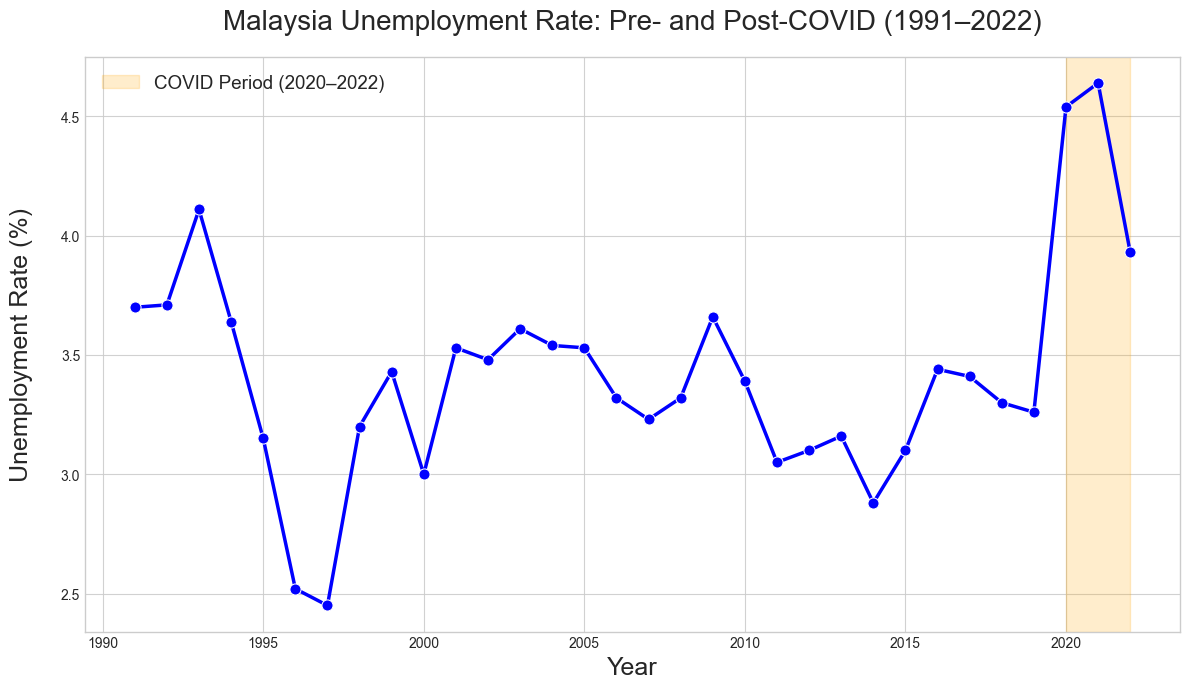

In [8]:

    
plt.style.use('seaborn-v0_8-whitegrid')

#fig is whiteboard behind the chart,ax is the plot or chart it self
fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(
    data=df_malaysia,
    x='Year',
    y='Unemployment Rate',
    color='blue',
    linewidth=2.5,
    marker='o',
    markersize=8,
    ax=ax
)

# Shade COVID period
#ax,axvspan is vertical shading or span
ax.axvspan(2020,2022, color='orange', alpha=0.2, label='COVID Period (2020–2022)')

ax.set_title('Malaysia Unemployment Rate: Pre- and Post-COVID (1991–2022)', fontsize=20,pad=20)
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Unemployment Rate (%)', fontsize=18,labelpad=20)
ax.grid(True, alpha=0.9)
ax.legend(fontsize=13.5)

plt.tight_layout()                    # ← moved BEFORE savefig
plt.savefig(IMAGE_DIR / "malaysia_unemployment_trend.png")
plt.show()

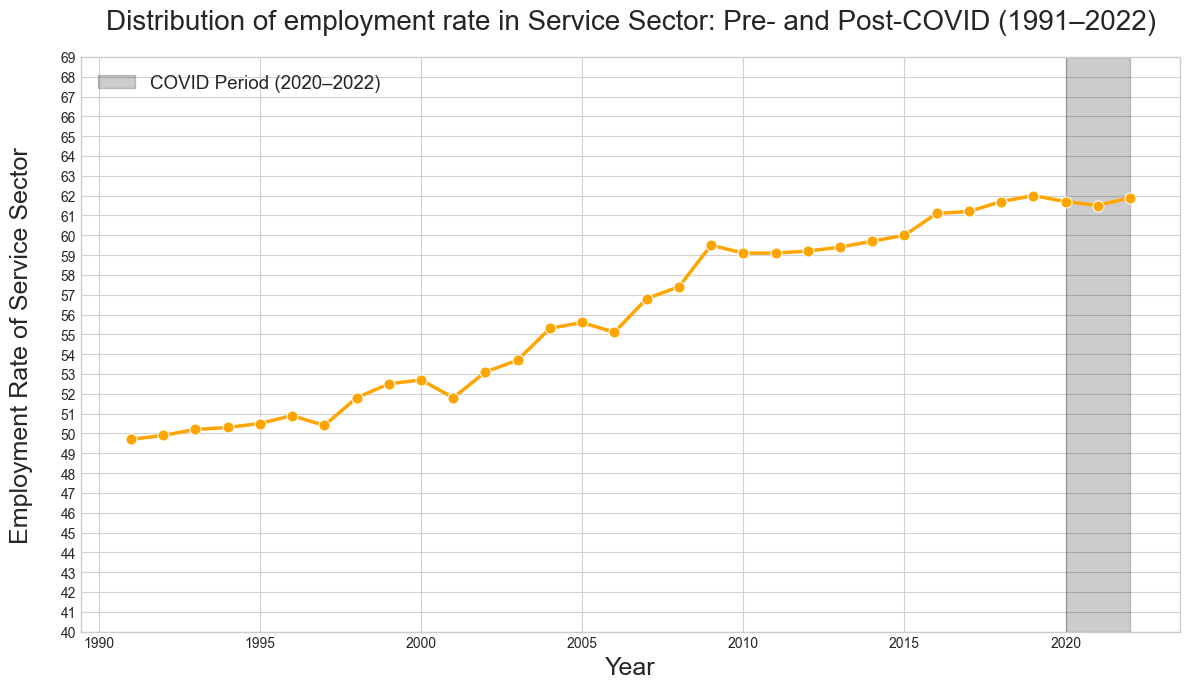

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')

#fig is whiteboard behind the chart,ax is the plot or chart it self
fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(
    data=df_malaysia,
    x='Year',
    y='Employment Sector: Services',
    color='orange',
    linewidth=2.5,
    marker='o',
    markersize=8,
    ax=ax
)

# Shade COVID period
#ax,axvspan is vertical shading or span
ax.axvspan(2020,2022, color='black', alpha=0.2, label='COVID Period (2020–2022)')

ax.set_title('Distribution of employment rate in Service Sector: Pre- and Post-COVID (1991–2022)', fontsize=20,pad=20)
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Employment Rate of Service Sector', fontsize=18,labelpad=20)
ax.grid(True, alpha=0.9)
ax.legend(fontsize=13.5) #help customize label

ax.set_yticks(np.arange(40, 70, 1))

plt.tight_layout()                    # ← moved BEFORE savefig
plt.savefig(IMAGE_DIR / "Distribution of Service Sector.png")
plt.show()

In [10]:
#try define another Visualization function lineplot
def line_plot(title,data,x,y,color,marker=None,xlabel=None,ylabel=None,save_name=None):


 plt.style.use('seaborn-v0_8-whitegrid')

 fig, ax = plt.subplots(figsize=(12, 7))

 sns.lineplot(
    data=data,
    x=x,
    y=y,
    color= color,
    linewidth=2.5,
    marker='o',
    markersize=8,
    ax=ax
  )

 # Shade COVID period
 #ax,axvspan is vertical shading or span
 ax.axvspan(2020,2022, color='black', alpha=0.3, label='COVID Period (2020–2022)')

 ax.set_title(title, fontsize=20,pad=20)
 ax.set_xlabel(xlabel or x, fontsize=18)
 ax.set_ylabel(ylabel or y, fontsize=18,labelpad=20)
 ax.grid(True, alpha=0.9)
 ax.legend(fontsize=13.5) #help customize label


 plt.tight_layout()                    # ← moved BEFORE savefig

 if save_name is None:
      save_name =title
 save_path = IMAGE_DIR / save_name  #here is define a file of a folder
 plt.savefig(save_path, dpi=300, bbox_inches='tight')
 print(f" lineplot saved: {save_path}")

plt.show()


 lineplot saved: c:\BEGIN\Malaysia-youth-unemployment-analysis\notebook\image_chart\Malaysia GDP in billion USD from 1990-2022


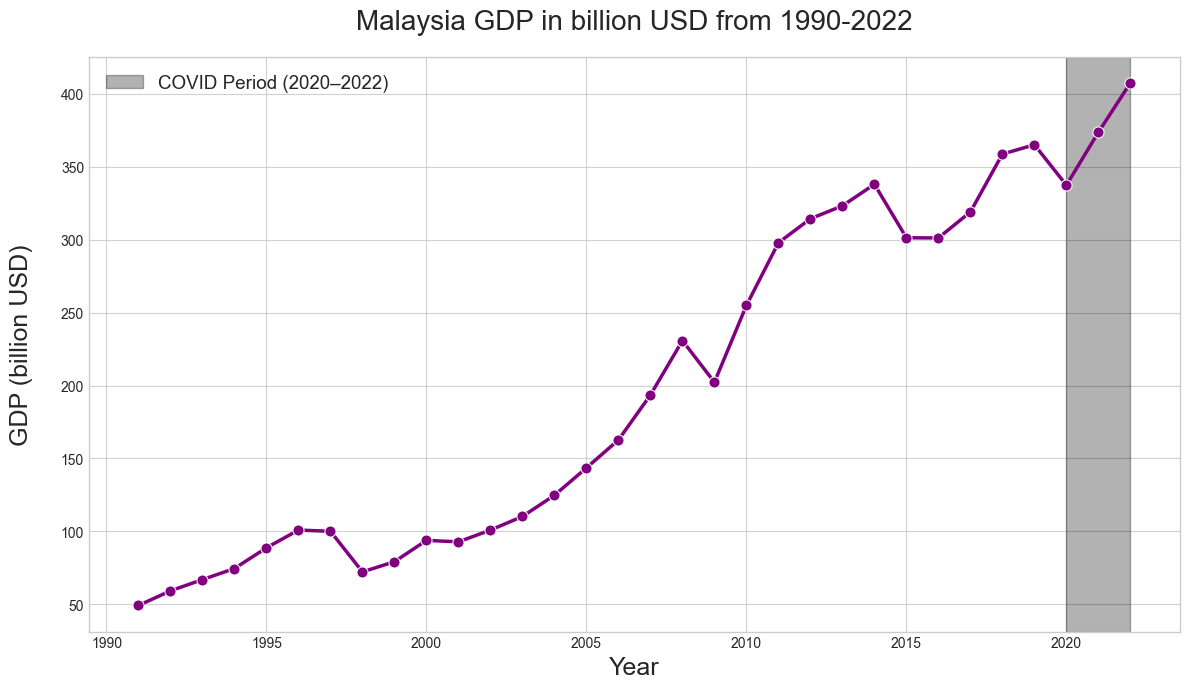

In [11]:
line_plot(title="Malaysia GDP in billion USD from 1990-2022",data=df_malaysia,x='Year',y="GDP (billion USD)",color="purple")

In [12]:
# we define a resusable histogram function 
def plot_histogram(df, column, title, xlabel=None, bins=15, hue=None, 
                   palette="viridis", save_name=None):
    #None is because they can dont need to put varible,like dont need say xlabel specifically ,
    #but column is necessary due to take data from data frame,
    # if didt say anything about bins and palette ,we will define as 15,and "viridis"

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    
    sns.histplot(
        data=df,
        x=column,                       #dont need to put Y variable becaz ,histogram or distributiono only need one variable
        bins=bins,                      #because Y axis is Freguency
        hue=hue,
        kde=True,                   
        palette=palette,
        alpha=0.7,
        ax=ax
    )
    
    # Nice formatting
    ax.set_title(title, fontsize=18, pad=15)
    ax.set_xlabel(xlabel or column, fontsize=14) # will dafault the name of column in dataframe when u  no define xlabel
    ax.set_ylabel("Frequency (Number of Years)", fontsize=14)
    ax.grid(True, alpha=0.9)
    
    if hue:
        plt.legend(title="COVID Period", labels=["Pre-COVID (1991-2019)", "COVID (2020-2022)"], 
                   fontsize=12)
    
    
    plt.tight_layout()
    
    # Auto-save
    if save_name is None:
        save_name = f"{column.lower().replace(' ', '_')}_histogram.png"
    save_path = IMAGE_DIR / save_name  #here is define a file of a folder
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f" Histogram saved: {save_path}")
    
    plt.show()

 Histogram saved: c:\BEGIN\Malaysia-youth-unemployment-analysis\notebook\image_chart\malaysia_gdp_histogram.png


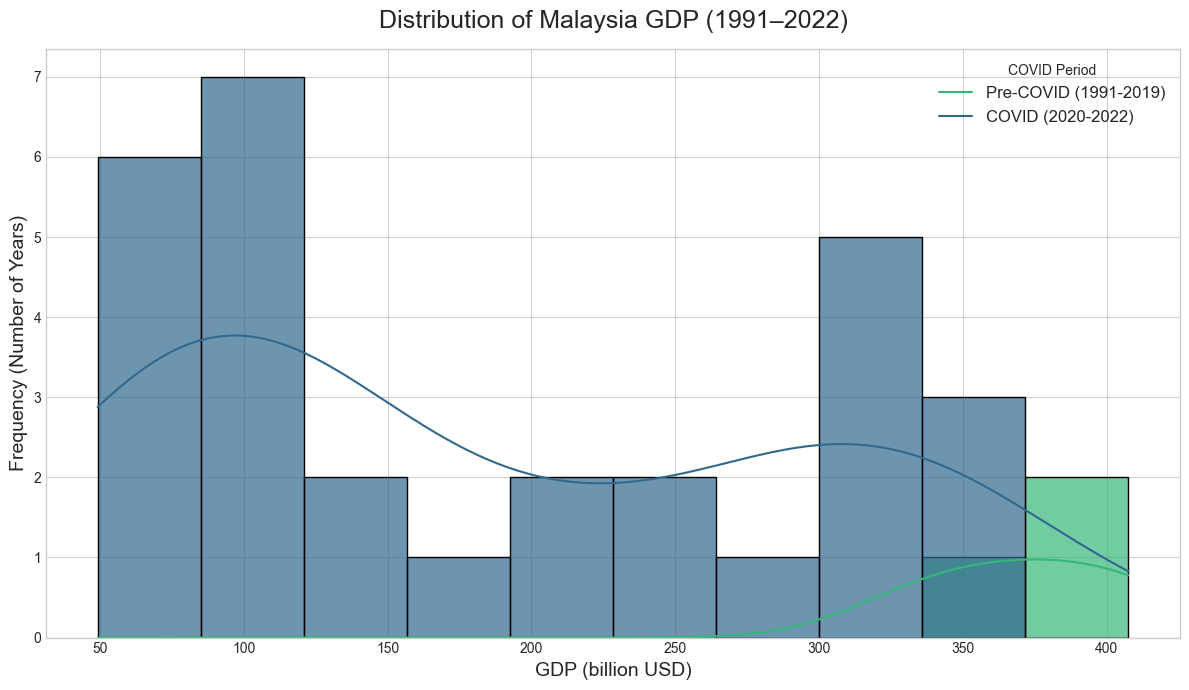

In [13]:
plot_histogram(
    df=df_malaysia,
    column='GDP (billion USD)',
    title='Distribution of Malaysia GDP (1991–2022)',
    xlabel='GDP (billion USD)',
    bins=10,
    hue="covid_period",
    save_name="malaysia_gdp_histogram.png"
     )     #we try use reusable histogram function for GDP of Malaysia



 Histogram saved: c:\BEGIN\Malaysia-youth-unemployment-analysis\notebook\image_chart\malaysia_services_histogram.png


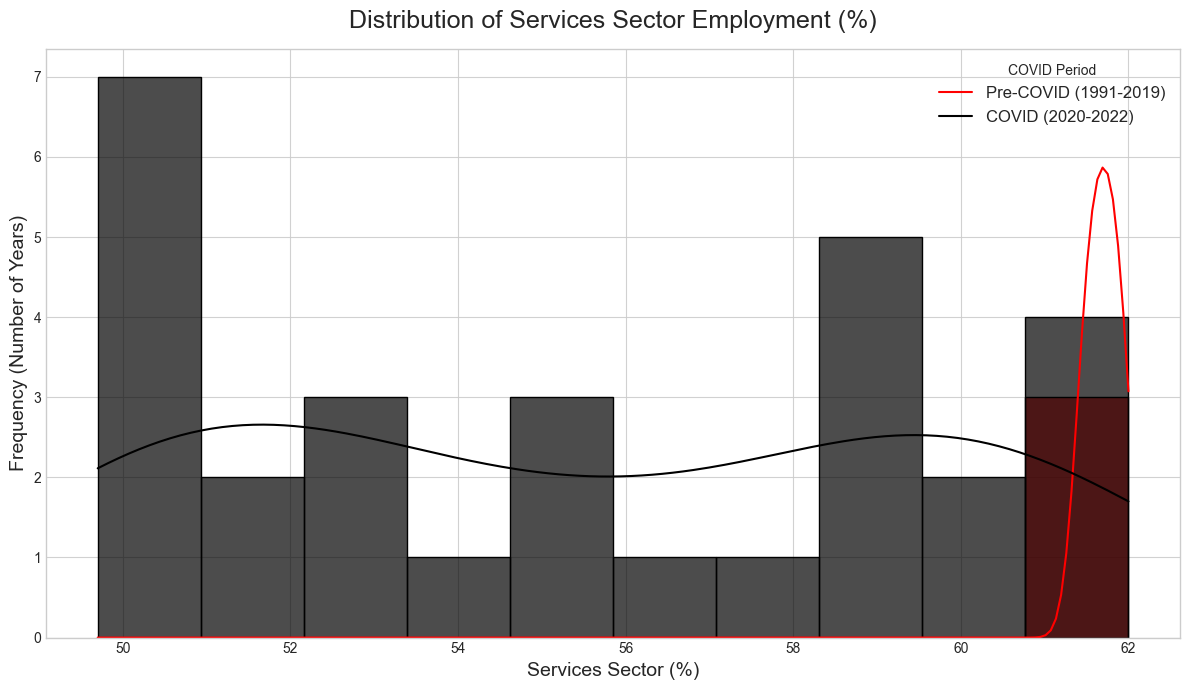

In [14]:
plot_histogram(
    df=df_malaysia,
    column='Employment Sector: Services',
    title='Distribution of Services Sector Employment (%)',
    xlabel='Services Sector (%)',
    bins=10,
    hue="covid_period",
    palette=["black","red"],
    save_name="malaysia_services_histogram.png"
)

 Histogram saved: c:\BEGIN\Malaysia-youth-unemployment-analysis\notebook\image_chart\malaysia_Agriculture_histogram.png


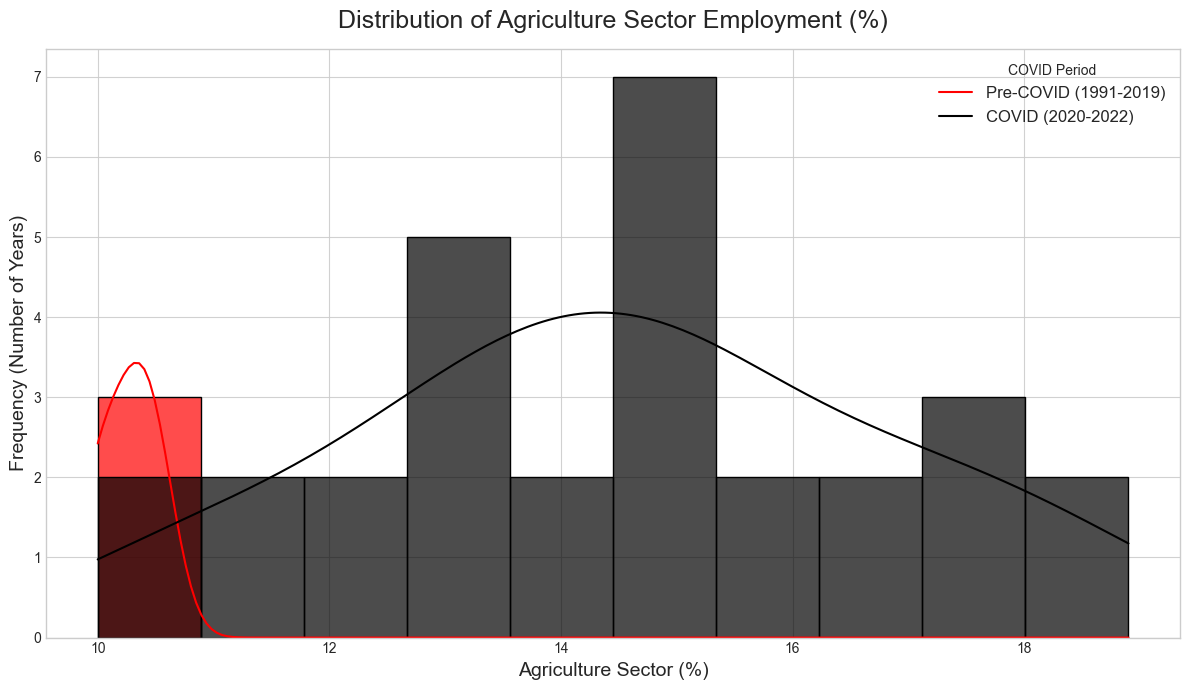

In [15]:
plot_histogram(
    df=df_malaysia,
    column='Employment Sector: Agriculture',
    title='Distribution of Agriculture Sector Employment (%)',
    xlabel='Agriculture Sector (%)',
    bins=10,
    hue="covid_period",
    palette=["black","red"],
    save_name="malaysia_Agriculture_histogram.png"
)

 Histogram saved: c:\BEGIN\Malaysia-youth-unemployment-analysis\notebook\image_chart\malaysia_Industry_histogram.png


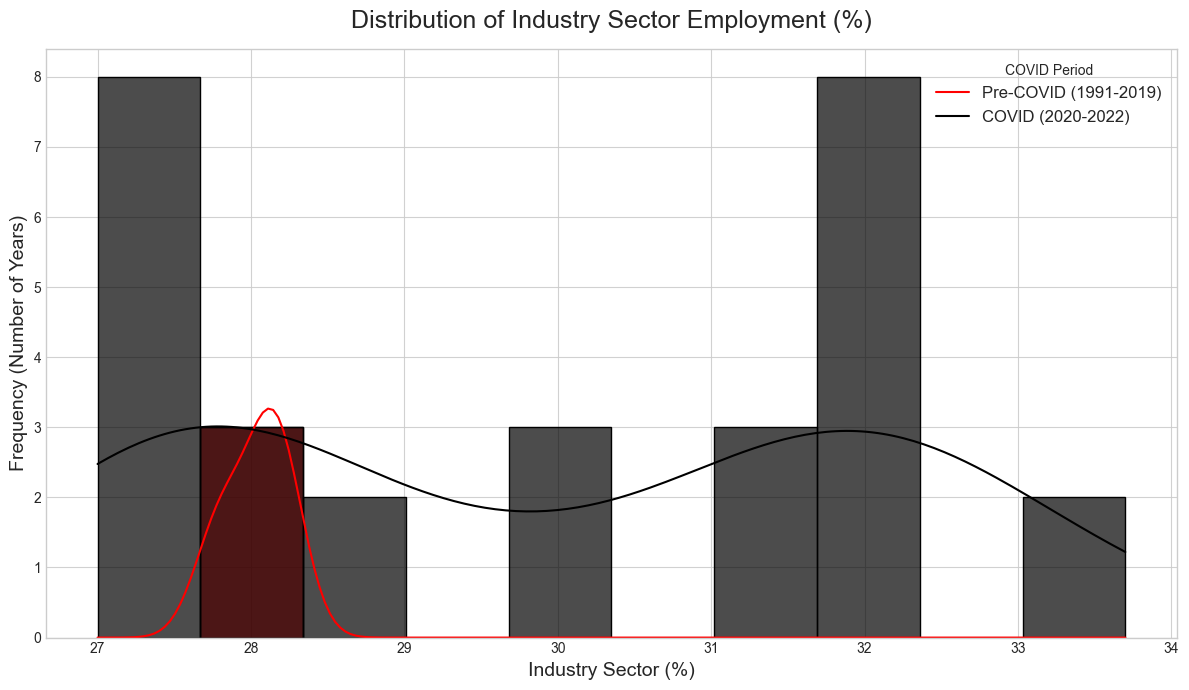

In [16]:
plot_histogram(
    df=df_malaysia,
    column='Employment Sector: Industry',
    title='Distribution of Industry Sector Employment (%)',
    xlabel='Industry Sector (%)',
    bins=10,
    hue="covid_period",
    palette=["black","red"],
    save_name="malaysia_Industry_histogram.png"
)

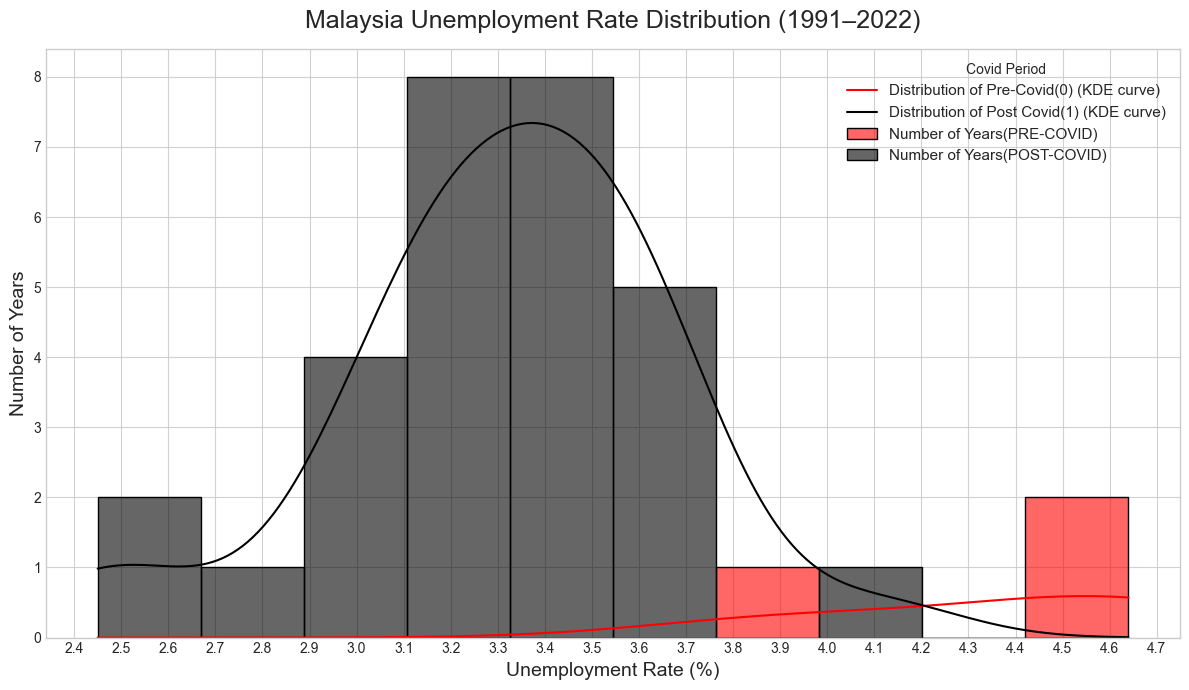

In [17]:

    

plt.style.use('seaborn-v0_8-whitegrid')   

fig, ax = plt.subplots(figsize=(12, 7))

sns.histplot(
    data=df_malaysia,
    x='Unemployment Rate',
    bins=10,
    kde=True,                    #rmb kde curve is the trend line or distribution,so its important to true

    hue='covid_period',           #hue is split the data ,covid_period in df_malaysia data frame
    palette=["black","red"],      #palette is color ,usually is coolwarm ,or customize use [" ,"]
    alpha=0.6
)

ax.set_xticks(np.arange(2.4,4.8, 0.1))

ax.set_title('Malaysia Unemployment Rate Distribution (1991–2022)', fontsize=18, pad=15)
ax.set_xlabel('Unemployment Rate (%)', fontsize=14)
ax.set_ylabel('Number of Years', fontsize=14)
ax.grid(True, alpha=0.9)

plt.legend(title= "Covid Period",
           
           labels=
            ["Distribution of Pre-Covid(0) (KDE curve)","Distribution of Post Covid(1) (KDE curve)",
            "Number of Years(PRE-COVID)","Number of Years(POST-COVID)"],fontsize=11)
plt.tight_layout()


   
plt.savefig(IMAGE_DIR/"Distribution of Malaysia Unemployment rate ")
plt.show()

In [18]:
pre_avg = df_malaysia[df_malaysia['covid_period'] == 0]['Unemployment Rate'].mean().round(2)
post_avg = df_malaysia[df_malaysia['covid_period'] == 1]['Unemployment Rate'].mean().round(2)

print("Key Insights:")
print(f"Pre-COVID average unemployment rate in Malaysia: {pre_avg}%")
print(f"Post-COVID average unemployment rate in Malaysia: {post_avg}%")
print(f"Change: {(post_avg - pre_avg):.2f} percentage points")
print("Unemployment increased noticeably after 2020 due to pandemic lockdowns and economic disruption.")
print("Recovery appears underway by 2022, but volatility remains higher than pre-COVID levels.")
print("Compared to regional peers, Malaysia's labour market resilience is relatively strong.")

Key Insights:
Pre-COVID average unemployment rate in Malaysia: 3.32%
Post-COVID average unemployment rate in Malaysia: 4.37%
Change: 1.05 percentage points
Unemployment increased noticeably after 2020 due to pandemic lockdowns and economic disruption.
Recovery appears underway by 2022, but volatility remains higher than pre-COVID levels.
Compared to regional peers, Malaysia's labour market resilience is relatively strong.


In [19]:
#Testing
df_malaysia.groupby("covid_period").agg({"Unemployment Rate": ["mean", "max"], 
                                         "unemp_change_pct": "mean"})


Unemployment Rate       unemp_change_pct
                          mean   max             mean
covid_period                                         
0                        3.318 4.110           -0.015
1                        4.370 4.640            0.223

In [20]:
df_malaysia["Year"].unique() #see value in this column(Year)u unique or not

array([1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [21]:
x=df_malaysia["Year"].nunique()
print(f"Number of Unique number is {x}")


Number of Unique number is 32
